# Step 1 Formulate Research Question

# Research Question

How do advertising budgets across TV, Radio, and Newspaper influence product sales?

# Objectives
1. To analyze the relationship between advertising channels and sales.
2. To build a multiple linear regression model using TV, Radio, and Newspaper as predictors.
3. To evaluate how accurately the model predicts sales.

# Variables
- Independent Variables (X):
  - TV Advertising Budget
  - Radio Advertising Budget
  - Newspaper Advertising Budget
- Dependent Variable (Y):
  - Sales

# Step 2 Data Cleaning and EDA

Step 2.1 Import Libraries

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

- pandas as pd: load and manipulate tabular data.
- matplotlib.pyplot as plt: create basic plots.
- seaborn as sns: create cleaner statistical visualizations.
- train_test_split: split data into training/testing sets.
- LinearRegression: build the regression model.
- mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error: evaluate prediction quality.

In short, this cell prepares everything for data prep, visualization, model training, and model evaluation.

Step 2.2 Load dataset

In [33]:
df = pd.read_csv("advertising.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


Step 2.3 Inspect Data

In [34]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


This is the output of df.head().

- Purpose: quickly preview the first 5 rows of your dataset.
- Interpretation: each row is one observation, and columns are:
    - TV, Radio, Newspaper = input features (predictors)
    - Sales = target/output you want to predict
    
Why it matters: confirms the file loaded correctly, column names are right, and values look reasonable before modeling.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB



df.info() gives a structural summary of your dataset.

- Total rows: 200 (index 0 to 199)
- Total columns: 4 (TV, Radio, Newspaper, Sales)
- Non-null count: 200 for every column
    - means no missing values in these columns
- Data type: all float64
    - good for linear regression
- Memory usage: about 6.4 KB

Purpose: verify data completeness and types before training the model.

In [36]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


df.describe() gives summary statistics for each numeric column.

- count=200 for all columns: all 200 rows have values.
- mean: average value (e.g., average Sales is about 15.13).
- std: spread/variability (higher means more variation).
- min, 25%, 50%, 75%, max: distribution checkpoints.

50% is the median.

Step 2.4 Check missing values

In [37]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

The target output is 0, it means there's no missing values

Step 2.5 Check duplicates

In [38]:
df.duplicated().sum()

np.int64(0)

If there's a duplicated data use the the function below but if the result above shows 0 it means that there's no duplicated data

function for removal of duplicated data:

df = df.drop_duplicates()

Step 2.6 Rename Columns for readability

In [39]:
df.columns = ["TV", "Radio", "Newspaper", "Sales"]

Step 2.7 Exploratory Data Analysis (EDA)

A. Scatter Plots (each features vs Sales)

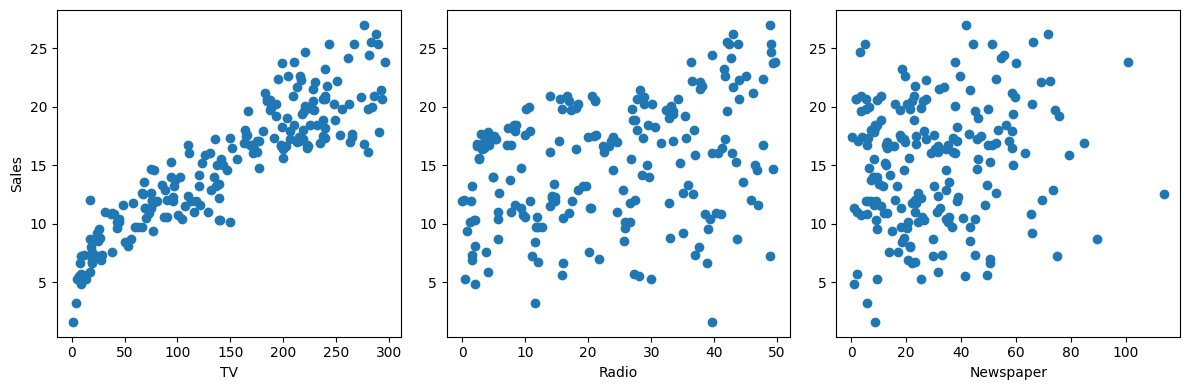

In [40]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV")
plt.ylabel("Sales")

plt.subplot(1,3,2)
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio")

plt.subplot(1,3,3)
plt.scatter(df["Newspaper"], df["Sales"])
plt.xlabel("Newspaper")

plt.tight_layout()
plt.show()

- TV → usually strong linear trend
- Radio → moderate trend
- Newspaper → weak relationship

Purpose: this cell creates three side-by-side scatter plots to visually check how each ad channel relates to Sales.

What each part does:

- plt.figure(figsize=(12,4)): sets one wide figure canvas.
- plt.subplot(1,3,1), ...2, ...3: splits figure into 1 row, 3 columns.
- plt.scatter(df["TV"], df["Sales"]) (and Radio/Newspaper): plots feature vs sales.
- plt.xlabel(...), plt.ylabel("Sales"): labels axes.
- plt.tight_layout(): prevents overlap.
- plt.show(): displays the plots.

Why this is important:
- Helps compare which feature has a stronger linear trend with Sales.
- Stronger, clearer upward pattern usually means better predictive signal.
- Useful EDA step before fitting multiple linear regression.

B. Correlation Matrix

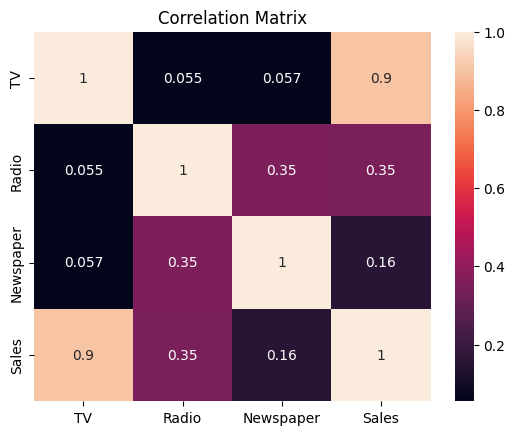

In [41]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

- TV has a strong positive correlation with Sales (0.90), so it is likely the most influential predictor.
- Radio has a moderate positive correlation (0.35), and Newspaper is weak (0.16).
- Predictors are not highly correlated with each other, so severe multicollinearity is unlikely.

This cell builds a correlation heatmap.

- df.corr(): computes pairwise Pearson correlations (from -1 to +1) for numeric columns.
- sns.heatmap(..., annot=True): draws the matrix and prints each correlation value inside the cells.
- plt.title(...) and plt.show(): labels and displays the figure.

Purpose in your workflow:
- See which features are most related to Sales.
- Check for multicollinearity (predictors highly correlated with each other), which can make multiple regression coefficients less stable.
- Decide which predictors are likely most useful before/while modeling.

How to read quickly:
- Near +1: strong positive relationship.
- Near -1: strong negative relationship.
- Near 0: weak linear relationship.

C. Pairplot

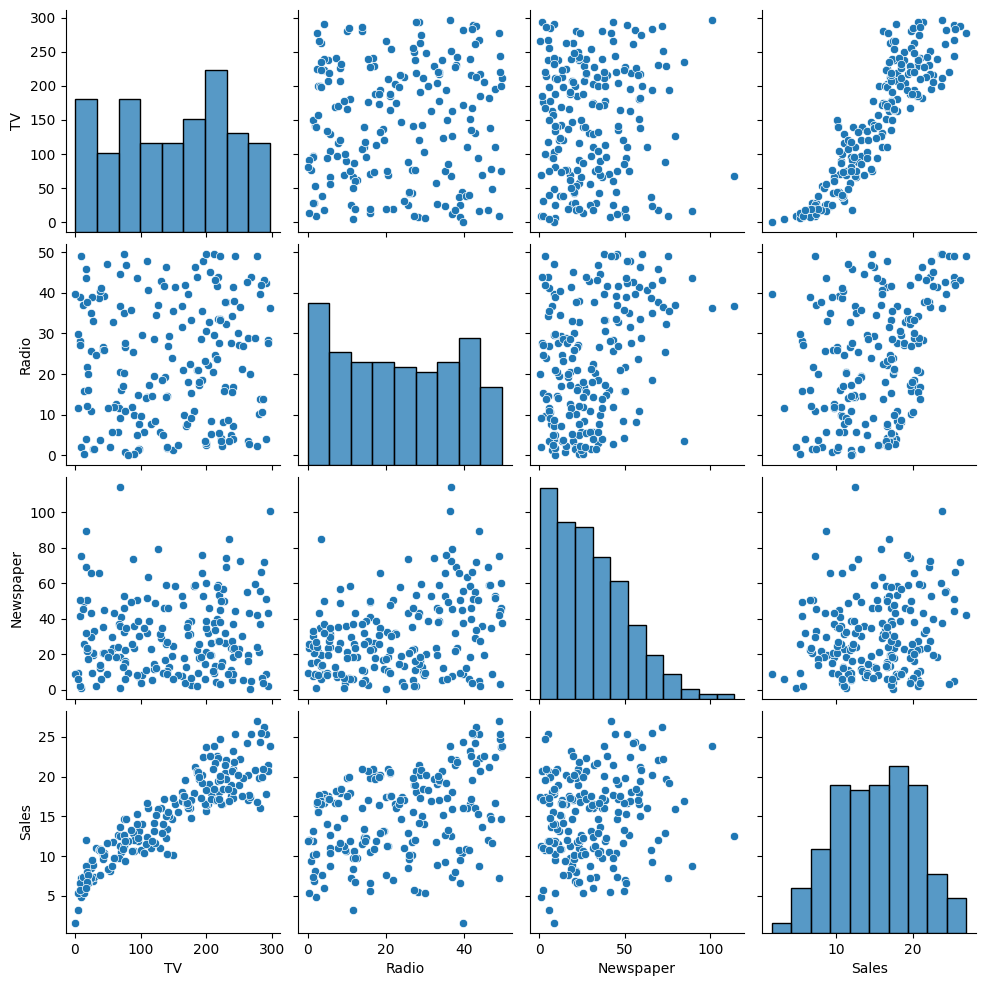

In [42]:
sns.pairplot(df)
plt.show()

- Sales shows the clearest positive relationship with TV, a moderate one with Radio, and a weak one with Newspaper.
- Most predictor-predictor relationships look weak, and Newspaper appears right-skewed.
- This supports using multiple regression, with TV likely contributing the most.

- sns.pairplot(df) creates a grid of plots showing:
    - Every variable vs every other variable (scatter plots),
    - Each variable’s own distribution on the diagonal.

# Step 3 Model Training

Step 3.1 Define X and Y

In [43]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

We will use TV, Radio, and Newspaper as input features and Sales as our outcome features

Step 3.2 Train-Test split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

This line splits your data into training and testing sets.

- X_train, y_train: used to train the model.
- X_test, y_test: used to evaluate model performance on unseen data.
- test_size=0.2: 20% test, 80% train.
- random_state=42: makes the split reproducible (same split every run).


Purpose: prevent overfitting and get a fair estimate of how well the model generalizes.

Step 3.3 Create Model

In [45]:
model = LinearRegression()

model = LinearRegression() creates/initializes the linear regression model object.

Purpose:

- sets up the algorithm you want to use,
- prepares default settings (or custom ones if provided), does not learn from data yet.
- Training happens only in the next step: model.fit(X_train, y_train).

Step 3.4 Train Model

In [46]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The purpose of model.fit(X_train, y_train) is to train the regression model.

It learns:
- the intercept (b0)
- the coefficients/slopes (b1, b2, ...) so it can model the relationship between inputs and target (y ≈ b0 + b1x1 + b2x2 + ...) and then make predictions on new data.

Step 3.5 View Coefficients

In [47]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients

Intercept: 4.714126402214127


,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


Coefficient Interpretation

Multiple Linear Regression Formula

The general formula for multiple linear regression with n independent variables is:

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3 + ... + \beta_nx_n$$

Where:
- $\hat{y}$ = predicted dependent variable (Sales)
- $\beta_0$ = intercept (constant term)
- $\beta_1, \beta_2, \beta_3, ..., \beta_n$ = coefficients of independent variables
- $x_1, x_2, x_3, ..., x_n$ = independent variables (features)

Model Equation

Substituting our model coefficients into the formula:

$$\text{Sales} = 4.71 + 0.0545 \times \text{TV} + 0.1009 \times \text{Radio} + 0.0043 \times \text{Newspaper}$$

Interpretation of Coefficients

Intercept: 4.71
- Baseline sales value when all advertising budgets are zero
- Represents inherent sales without any advertising

Feature Coefficients

| Feature | Coefficient | Interpretation |
|---------|------------|-----------------|
| **TV** | 0.0545 | For every unit increase in TV advertising budget, sales increase by **0.0545 units** (holding other variables constant) |
| **Radio** | 0.1009 | For every unit increase in Radio advertising budget, sales increase by **0.1009 units** (holding other variables constant) |
| **Newspaper** | 0.0043 | For every unit increase in Newspaper advertising budget, sales increase by **0.0043 units** (holding other variables constant) |

Key Insights

1. **Ranking by Effectiveness**
- **Radio** is the **most effective** advertising channel
- **TV** is moderately effective
- **Newspaper** is the **least effective** advertising channel

2. **Comparative Analysis**
- Radio is **~1.85x more effective** than TV
- Radio is **~23x more effective** than Newspaper
- TV is **~12.6x more effective** than Newspaper

3. **Business Recommendation**
 - **Prioritize Radio** advertising for maximum sales impact  
 - **TV** advertising should be secondary choice  
 - **Newspaper** advertising appears to have minimal ROI - consider reducing or reallocating this budget

Step 3.7 Make Predictions

In [48]:
y_pred = model.predict(X_test)

Step 3.7 Compare results

In [49]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.head()

,Actual,Predicted
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719


# Step 4 Performance Evaluation

Step 4.1 Cmpute Metrics

In [50]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.2748262109549338
MSE: 2.9077569102710896
RMSE: 1.7052146229349223
R²: 0.9059011844150826


Model Evaluation Metrics

Why These Metrics Matter

- **MAE (Mean Absolute Error)**: Average absolute prediction error.  
  Purpose: tells us, in target units, how wrong predictions are on average.

- **MSE (Mean Squared Error)**: Average squared prediction error.  
  Purpose: penalizes larger errors more strongly than MAE.

- **RMSE (Root Mean Squared Error)**: Square root of MSE.  
  Purpose: gives error size in the same units as the target, while still emphasizing large errors.

- **R² (Coefficient of Determination)**: Proportion of variance explained by the model.  
  Purpose: measures how well the model performs compared to predicting the mean.


Step 4.3 Visualization of Actual vs Predicted

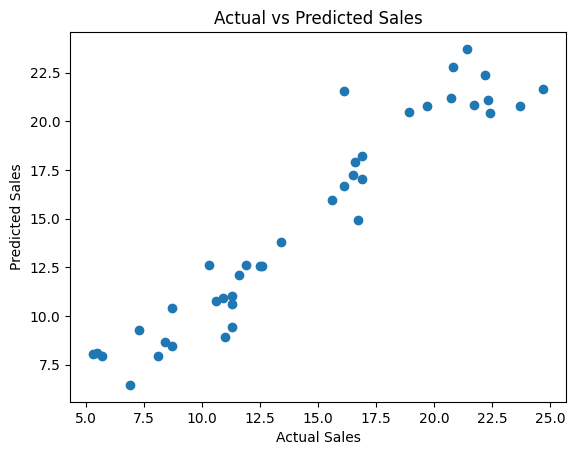

In [51]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


- Predicted sales increase with actual sales, showing the model captures the overall trend well.
- Most points are close to a diagonal pattern, so prediction errors are generally moderate, with a few deviations.

Step 4.4 Residuals

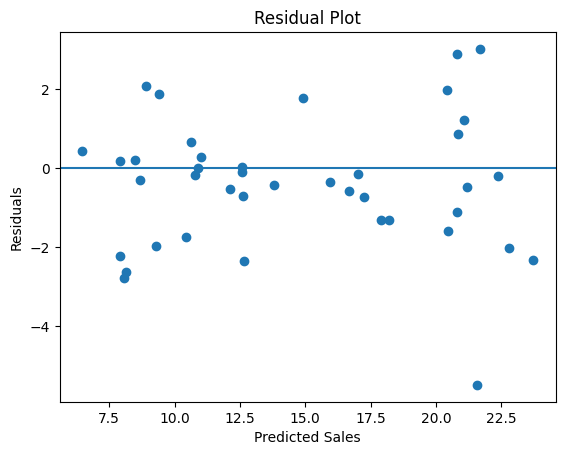

In [52]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Interpretation:

Residuals are mostly scattered around the zero line with no strong pattern, which is generally good, but there are a few larger outliers that suggest some predictions are less accurate.

Purpose:

Check model fit quality and assumptions (especially whether errors are random around zero)

Step 4.5 Predict New Data

In [53]:
new_data = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [20]
})

prediction = model.predict(new_data)
print("Predicted Sales:", prediction[0])

Predicted Sales: 15.50088402406167


Purpose:

use the trained model to predict sales for a new advertising budget scenario.

Interpretation: 

with TV=150, Radio=25, and Newspaper=20, the model predicts sales of about 15.5.
This is an estimate based on learned historical patterns, not an exact guaranteed value.

Step 4.6 Export Trained Model

Now that the regression model is trained, the next step is to save the fitted model object to a file using Python's `pickle` module. This exported `.pkl` file can be loaded later by other applications, a web demo, or deployment pipelines without rerunning the training process.

In [3]:
%pip install pandas scikit-learn

import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

if "model" not in globals():
    # If the trained model is not already available in this session, train it first.
    if "df" not in globals():
        df = pd.read_csv("advertising.csv")
        df.columns = ["TV", "Radio", "Newspaper", "Sales"]
    X = df[["TV", "Radio", "Newspaper"]]
    y = df["Sales"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

export_path = "advertising_model.pkl"
with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

Note: you may need to restart the kernel to use updated packages.
Trained model exported to advertising_model.pkl
